In [9]:
import sys
sys.path.append('../..')

import os
import json
import qiskit
import pytket
import pytket.qasm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import reduce
from typing import List
from phoenix import gates, Circuit, models
from phoenix.utils.ops import tensor_slots
from phoenix.utils.functions import infidelity
from scipy.stats import gmean
import warnings

warnings.filterwarnings("ignore")

selected_molecules = ['LiH_frz_BK_sto3g', 'LiH_frz_JW_sto3g', 'NH_frz_BK_sto3g', 'NH_frz_JW_sto3g']

In [10]:
def ideal_evolution(json_fname):
    with open(json_fname, 'r') as f:
        data = json.load(f)
    ham = models.HamiltonianModel(data['paulis'], data['coeffs'])
    u = ham.unitary_evolution()
    return u

def qiskit_O3_all2all(circ: qiskit.QuantumCircuit) -> qiskit.QuantumCircuit:
    from itertools import combinations
    for q0, q1 in combinations(range(circ.num_qubits), 2):
        circ.cx(q0, q1)
        circ.cx(q0, q1)
    circ = qiskit.transpile(circ, optimization_level=3, basis_gates=['u1', 'u2', 'u3', 'cx'])
    return circ

def qiskit_to_unitary(qc):
    import cirq
    import qiskit.qasm2
    from cirq.contrib.qasm_import import circuit_from_qasm
    circ = circuit_from_qasm(qiskit.qasm2.dumps(qc))
    return cirq.unitary(circ)

def constr_tket_circuit(paulis: List[str], coeffs: List[float]) -> pytket.Circuit:
    from pytket.circuit import PauliExpBox
    from pytket.pauli import Pauli

    pauli_str_map = {
        'X': Pauli.X,
        'Y': Pauli.Y,
        'Z': Pauli.Z,
    }

    def get_qubits_acted(pauli: str) -> List[int]:
        """Get the qubits acted by a Pauli string."""
        return [i for i, p in enumerate(pauli) if p != 'I']

    circ = pytket.Circuit(len(paulis[0]))

    for pauli, coeff in zip(paulis, coeffs):
        qubits = get_qubits_acted(pauli)
        if len(qubits) == 0:
            continue
        pauli_box = PauliExpBox([pauli_str_map[pauli[q]] for q in qubits], t=coeff * 2 / np.pi)
        circ.add_gate(pauli_box, qubits)

    return circ

def tket_pass(paulis: List[str], coeffs: List[float]) -> pytket.Circuit:
    circ = constr_tket_circuit(paulis, coeffs)    
    pytket.passes.PauliSimp().apply(circ)
    # ! full peephole optimization with all_swaps=False: because when allow_swaps=True there might be implicit swaps
    pytket.passes.FullPeepholeOptimise(allow_swaps=False).apply(circ)

    return circ

def phoenix_pass(ham):
    # front_x_gates = [gates.X.on(q) for q in data['front_x_on']]
    circ = ham.phoenix_circuit()
    # circ.prepend(*front_x_gates)
    circ = qiskit_O3_all2all(circ.to_qiskit())
    return circ

In [13]:
infid_tket = []
infid_phoenix = []

# algo_err = {
#     '1e-2': {'tket': [], 'phoenix': []},
#     '1e-1': {'tket': [], 'phoenix': []},
#     '1e0': {'tket': [], 'phoenix': []},
#     '1e1': {'tket': [], 'phoenix': []},
#     '1e2': {'tket': [], 'phoenix': []},
#     # '1e3': {'tket': [], 'phoenix': []},
# }
# amplitudes = [1e-1, 1e0, 1e1, 1e2]
# amplitudes = [0.5, 1, 2, 3, 4, 5, 6]
amplitudes = [0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8]

tket_algo_err = {mol: [] for mol in selected_molecules}
phoenix_algo_err = {mol: [] for mol in selected_molecules}


for mol in selected_molecules:
    print()
    print('Molecule:', mol)
    json_fname = '../benchmarks/uccsd/{}.json'.format(mol)

    with open(json_fname, 'r') as f:
        data = json.load(f)

    for amp in amplitudes:
        ham = models.HamiltonianModel(data['paulis'], data['coeffs'])
        ham.coeffs *= amp
        u = ham.unitary_evolution()
        circ = ham.generate_circuit()

        circ_tket = tket_pass(ham.paulis, ham.coeffs)
        circ_phoenix = phoenix_pass(ham)

        tket_algo_err[mol].append(infidelity(circ_tket.get_unitary(), u))
        phoenix_algo_err[mol].append(infidelity(qiskit_to_unitary(circ_phoenix), u))

        print('Amp={} infidelity: TKet {:.6f}, Phoenix {:.6f}'.format(amp, tket_algo_err[mol][-1], phoenix_algo_err[mol][-1]))


Molecule: LiH_frz_BK_sto3g
Amp=0.6 infidelity: TKet 0.000111, Phoenix 0.000050
Amp=0.8 infidelity: TKet 0.000349, Phoenix 0.000157
Amp=1 infidelity: TKet 0.000845, Phoenix 0.000382
Amp=1.2 infidelity: TKet 0.001729, Phoenix 0.000784
Amp=1.4 infidelity: TKet 0.003156, Phoenix 0.001438
Amp=1.6 infidelity: TKet 0.005290, Phoenix 0.002426
Amp=1.8 infidelity: TKet 0.008306, Phoenix 0.003834

Molecule: LiH_frz_JW_sto3g
Amp=0.6 infidelity: TKet 0.000111, Phoenix 0.000081
Amp=0.8 infidelity: TKet 0.000349, Phoenix 0.000253
Amp=1 infidelity: TKet 0.000845, Phoenix 0.000611
Amp=1.2 infidelity: TKet 0.001729, Phoenix 0.001252
Amp=1.4 infidelity: TKet 0.003156, Phoenix 0.002287
Amp=1.6 infidelity: TKet 0.005290, Phoenix 0.003837
Amp=1.8 infidelity: TKet 0.008306, Phoenix 0.006031

Molecule: NH_frz_BK_sto3g
Amp=0.6 infidelity: TKet 0.000538, Phoenix 0.000208
Amp=0.8 infidelity: TKet 0.001672, Phoenix 0.000651
Amp=1 infidelity: TKet 0.003996, Phoenix 0.001574
Amp=1.2 infidelity: TKet 0.008071, Phoe

In [107]:
selected_molecules

['LiH_frz_BK_sto3g', 'LiH_frz_JW_sto3g', 'NH_frz_BK_sto3g', 'NH_frz_JW_sto3g']

In [ ]:
# 5 Molecule: TKet 0.249304, Phoenix 0.185308

# result = pd.DataFrame({
#     'amp': amplitudes,
#     'tket': tkt_algo_err,
result_tket = pd.DataFrame(tket_algo_err)
result_phoenix = pd.DataFrame(phoenix_algo_err)
result_tket['amp'] = amplitudes
result_phoenix['amp'] = amplitudes
result_tket.to_csv('./results/algo_err_tket.csv', index=False)
result_phoenix.to_csv('./results/algo_err_phoenix.csv', index=False)

In [15]:
result_tket

,LiH_frz_BK_sto3g,LiH_frz_JW_sto3g,NH_frz_BK_sto3g,NH_frz_JW_sto3g,amp
0,0.000111,0.000111,0.000538,0.000538,0.6
1,0.000349,0.000349,0.001672,0.001672,0.8
2,0.000845,0.000845,0.003996,0.003996,1.0
3,0.001729,0.001729,0.008071,0.008071,1.2
4,0.003156,0.003156,0.014489,0.014489,1.4
5,0.005290,0.005290,0.023825,0.023825,1.6
6,0.008306,0.008306,0.036588,0.036588,1.8


In [16]:
result_phoenix

,LiH_frz_BK_sto3g,LiH_frz_JW_sto3g,NH_frz_BK_sto3g,NH_frz_JW_sto3g,amp
0,0.000050,0.000081,0.000208,0.000297,0.6
1,0.000157,0.000253,0.000651,0.000923,0.8
2,0.000382,0.000611,0.001574,0.002209,1.0
3,0.000784,0.001252,0.003224,0.004469,1.2
4,0.001438,0.002287,0.005884,0.008040,1.4
5,0.002426,0.003837,0.009864,0.013260,1.6
6,0.003834,0.006031,0.015486,0.020441,1.8


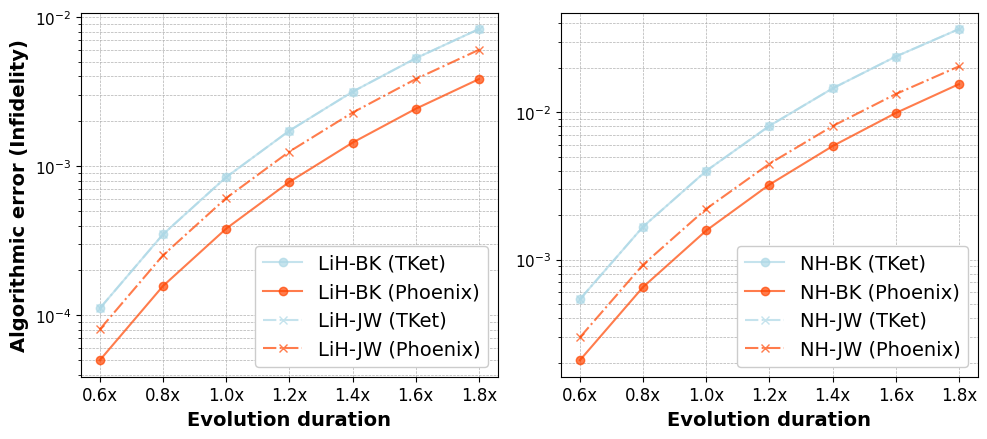

In [17]:
plt.figure(figsize=(10, 4.5))


# LiH 
plt.subplot(1, 2, 1)
plt.plot(result_tket['amp'], result_tket['LiH_frz_BK_sto3g'], label='LiH-BK (TKet)', marker='o', color='lightblue', linestyle='-', alpha=0.7)
plt.plot(result_phoenix['amp'], result_phoenix['LiH_frz_BK_sto3g'], label='LiH-BK (Phoenix)', marker='o', color='#FF4500', linestyle='-', alpha=0.7)
plt.plot(result_tket['amp'], result_tket['LiH_frz_JW_sto3g'], label='LiH-JW (TKet)', marker='x', color='lightblue', linestyle='-.', alpha=0.7)
plt.plot(result_phoenix['amp'], result_phoenix['LiH_frz_JW_sto3g'], label='LiH-JW (Phoenix)', marker='x', color='#FF4500', linestyle='-.', alpha=0.7)

plt.xlabel('Evolution duration', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=11)
plt.ylabel('Algorithmic error (Infidelity)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=14, framealpha=1)
plt.yscale('log')
plt.grid(which='both', linestyle='--', linewidth=0.5)

# let xtick to be 'x' to represent times
plt.gca().set_xticklabels(['x'] + [str(x) for x in amplitudes[1:]], fontsize=12)
def format_func(value, tick_number):
    return f'{value:.1f}x'
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_func))

# NH
plt.subplot(1, 2, 2)
plt.plot(result_tket['amp'], result_tket['NH_frz_BK_sto3g'], label='NH-BK (TKet)', marker='o', color='lightblue', linestyle='-', alpha=0.7)
plt.plot(result_phoenix['amp'], result_phoenix['NH_frz_BK_sto3g'], label='NH-BK (Phoenix)', marker='o', color='#FF4500', linestyle='-', alpha=0.7)
plt.plot(result_tket['amp'], result_tket['NH_frz_JW_sto3g'], label='NH-JW (TKet)', marker='x', color='lightblue', linestyle='-.', alpha=0.7)
plt.plot(result_phoenix['amp'], result_phoenix['NH_frz_JW_sto3g'], label='NH-JW (Phoenix)', marker='x', color='#FF4500', linestyle='-.', alpha=0.7)

plt.xlabel('Evolution duration', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)


# let xtick to be 'x' to represent times
plt.gca().set_xticklabels(['x'] + [str(x) for x in amplitudes[1:]], fontsize=12)
def format_func(value, tick_number):
    return f'{value:.1f}x'
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_func))

plt.yticks(fontsize=11)
# plt.ylabel('Algorithmic error (Infidelity)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=14, framealpha=1)
plt.yscale('log')
plt.grid(which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()

plt.savefig('./figures/algo_err.pdf')

plt.show()